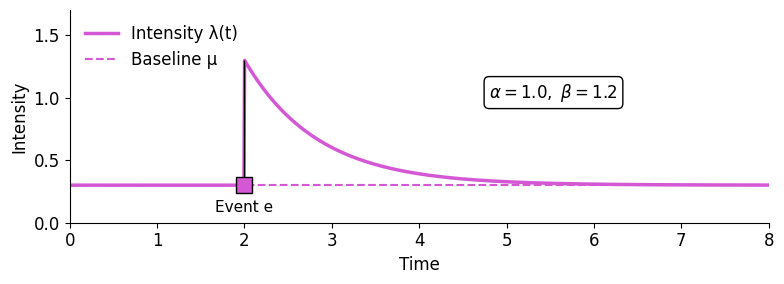

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Simple Hawkes Process plot
# ---------------------------

plt.rcParams["figure.figsize"] = (8, 3)
plt.rcParams["font.size"] = 12

# Time grid
T = 8
t = np.linspace(0, T, 1000)

# Parameters
mu = 0.3              # baseline
alpha = 1.0           # jump size
beta = 1.2            # decay rate

# One event at t = 2
t_event = 2.0

# Intensity function
lambda_t = np.full_like(t, mu)
mask = t >= t_event
lambda_t[mask] = mu + alpha * np.exp(-beta * (t[mask] - t_event))

# Baseline line
baseline = np.full_like(t, mu)

# Plot
fig, ax = plt.subplots()

# Intensity curve
ax.plot(t, lambda_t, color="#d458d4", lw=2.5, label="Intensity λ(t)")
ax.plot(t, baseline, color="#d458d4", ls="--", lw=1.5, label="Baseline μ")

# Event marker
ax.scatter([t_event], [mu], color="#d458d4", edgecolor="black", s=120, marker="s",
           zorder=3)

# Label “Event e”
ax.text(t_event, mu - 0.12, "Event e", ha="center", va="top", fontsize=11)

# Vertical line showing the jump
ax.vlines(t_event, mu, mu + alpha, colors="black", lw=1)

# Display alpha and beta in the figure
text_x = T * 0.60
text_y = mu + alpha * 0.7

ax.text(
    text_x,
    text_y,
    fr"$\alpha = {alpha},\ \beta = {beta}$",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)

# Style
ax.set_xlabel("Time")
ax.set_ylabel("Intensity")
ax.set_ylim(0, mu + alpha + 0.4)
ax.set_xlim(0, T)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("hawkes_simple_with_params.png", dpi=300, bbox_inches="tight")
plt.show()
